In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Пусть $\xi_1, \xi_2,...$ - последовательность независимых случайных величин из хи-квадрат распределения с 3 степенями свободы.   
### Привести графическую иллюстрацию закона больших чисел.

Начнем с определений, что вообще такое хи-квадрат распределение с 3 степенями свободы?

**Определение** - $\chi^2$ распределение с $k \in \mathbb{N}$ степенями свободы - это распределение суммы квадратов $k$ независимых стандартных нормальных случайных величин, т.е. такого набора $\zeta_1, \zeta_2,... : \zeta_i \sim N(0,1) \ i \in \{1,2,...k\}$

Соответственно, функция распределения $\xi \sim \chi^2 = \sum{\zeta_i^2}, \ \zeta_i \sim N(0,1), \ i \in \{1,2,...,k\}$ - это   
$F_{\xi}(t) = \mathbb{P}(\xi \in (-\inf, t)) = \mathbb{P}(\xi < t)$

$\chi^2(k)$ распределение - это частный случай Гамма распределения, в частности: $\xi \sim \chi^2(k) \Longrightarrow \xi \sim Gamma(a=\frac{k}{2}, \theta = 2)$ 

С распределением вроде разобрались. Построим себе для наглядности графики функции распределения  
 и плотности для каждого $\zeta_i$

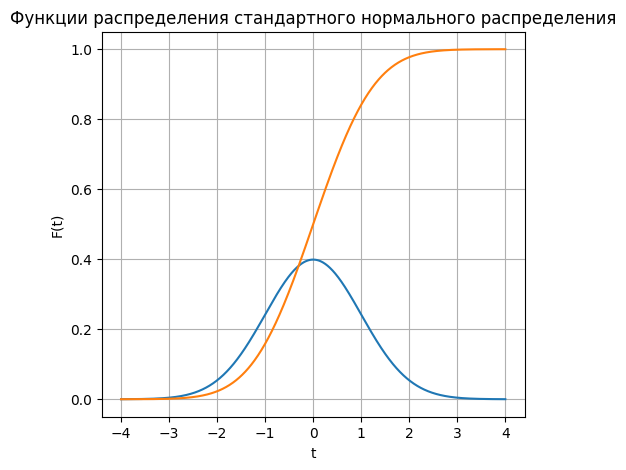

In [2]:
"""
Воспользуемся для этого библиотекой scipy
"""

from scipy.stats import norm

t = np.linspace(-4,4,1000)

pdf = norm.pdf(t)
cdf = norm.cdf(t)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(t, pdf)
plt.title("Плотность стандартного нормального распределения")
plt.xlabel("t")
plt.ylabel("f(t)")

plt.subplot(1,2,1)
plt.plot(t, cdf)
plt.title("Функции распределения стандартного нормального распределения")
plt.xlabel("t")
plt.ylabel("F(t)")
plt.grid()

plt.show()

Нас просят привести графическую интерпретацию закона больших чисел. Давайте вспомним, что это такое!

Говорим, что последовательность случайных величин $\xi_1, \xi_2,...$ с конечными первыми моментами (т.е. $\mathbb{E}(\xi_i) < \infty , \ i \in \mathbb{N})$ удовлетворяет **закону больших чисел** **(ЗБЧ)**, если:   
$$\frac{\xi_1 + ... + \xi_n}{n} - \frac{\mathbb{E}(\xi_1)+...+\mathbb{E}(\xi_n)}{n} \xrightarrow{p} 0, \ n \rightarrow \infty \ \ (1)$$

Где последовательность случайных величин $\zeta_n \xrightarrow{p} 0 , \ n \rightarrow \infty \Longleftrightarrow$   
$\Longleftrightarrow \forall \epsilon > 0 \ : \ \mathbb{P}(|\zeta_n - 0| \geq \epsilon) \rightarrow 0 \ , \ n \rightarrow \infty \equiv \forall \epsilon > 0 \ : \ \mathbb{P}(|\zeta_n| \geq \epsilon) \rightarrow 0 \ , \ n \rightarrow \infty$

Соответственно **законами больших чисел** принято называть утверждения о том, **при каких условиях** последовательность случайных величин удовлетворяет **закону больших чисел**, т.е. выполняется свойство (1)

По условию задачи мы работаем с последовательностью независимых и одинаково распределенных случайных величин, соответственно, можно воспользоваться **ЗБЧ Чебышёва**:     
$$ \frac{\xi_1 + ... + \xi_n}{n} \xrightarrow{p} \mathbb{E}(\xi_1) \ , n \rightarrow \infty \ \ \ (2)$$

Для его выполнения нам нужно требовать конечность первого момента $\xi_i$, поэтому давайте посчитаем его.

$\xi_i = \xi_1 = \xi \sim \chi^2(3) \Longrightarrow \xi = \zeta_1^2 + \zeta_2^2 + ... + \zeta_k^2, \ \zeta_i = \zeta \sim N(0,1) \Longrightarrow$  
$$\Longrightarrow \mathbb{E}(\xi) = \mathbb{E}(\sum_{i=1}^{k=3}{(\zeta_i^2)}) = \sum_{i=1}^{k=3}{\mathbb{E}(\zeta_i^2)} = \sum_{i=1}^{k=3}{1} = k = 3\Longrightarrow$$
$\Longrightarrow \mathbb{E}(\xi) = 3$

Аналогичными рассуждениями определим дисперсию $\xi_i$  
$\xi_i = \xi_1 = \xi \sim \chi^2(3) \Longrightarrow \xi = \zeta_1^2 + \zeta_2^2 + ... + \zeta_k^2, \ \zeta_i = \zeta \sim N(0,1) \Longrightarrow$  
$$\Longrightarrow \mathbb{D}(\xi) = \mathbb{D}(\sum_{i=0}^{k=3}{(\zeta_i^2)}) = \sum_{i=1}^{k=3}{\mathbb{D}(\zeta_i^2)} = \sum_{i=1}^{k=3}{\mathbb{E}(\zeta_i^4) - (\mathbb{E}(\zeta_i^2))^2} = \sum_{i=1}^{k=3}{3 - 1} = \sum_{i=1}^{k=3}{2} = 6  \Longrightarrow$$
$\Longrightarrow \mathbb{D}(\xi) = 6$

Соответственно, остается показать верность (2) при увеличении n. 

In [3]:
"""
Сгенерируем выборку, из которой будет состоять наша последовательность случайных величин
"""

N = 2000

xi = np.random.chisquare(df=3, size=N)

print(xi)

[0.44103308 8.2256938  3.0836873  ... 2.61229822 6.94062262 6.8223306 ]


In [4]:
"""
Найдем кумулятивную сумму (S_n) и вычислим выборочное среднее для каждого из n = 1, 2, ... , N
"""

S_n = np.cumsum(xi)

sample_mean = S_n / np.arange(1, N+1)

print(f"S_n = {S_n}, \n")

print(f"sample_mean = {sample_mean}, \n")

S_n = [4.41033076e-01 8.66672688e+00 1.17504142e+01 ... 5.84805163e+03
 5.85499225e+03 5.86181458e+03], 

sample_mean = [0.44103308 4.33336344 3.91680473 ... 2.92695277 2.9289606  2.93090729], 



In [5]:
"""
Заранее обернем это в функцию
"""

def sample(N):

    xi = np.random.chisquare(df=3, size=N)

    S_n = np.cumsum(xi)

    sample_mean = S_n / np.arange(1, N+1)

    return sample_mean

Зададим на графике вертикальную отсечку, равную той точке, в которой разница последней четверти выборочного среднего отличается от ответа не больше, чем стандартное отклоенение.

Чему же будет равно это отклонение? 

$\sigma(\frac{S_n}{n}) = \sqrt{\mathbb{D}(\frac{S_n}{n})} = \sqrt{\frac{6}{n}}$

In [6]:
def illustration(sample_mean):
    N = len(sample_mean)
    n = np.arange(1, N + 1)

    target = 3
    eps = 0.01
    sigma_mean = np.sqrt(6 / n)

    # 1) Отсечка по константе 0.01
    inside_eps = np.abs(sample_mean - target) <= eps

    # 2) Отсечка по динамической границе sqrt(6/n)
    inside_sigma = np.abs(sample_mean - target) <= sigma_mean

    # suffix_all_true[i] = True, если начиная с i и до конца все значения True
    suffix_eps = np.flip(np.cumprod(np.flip(inside_eps.astype(int)))).astype(bool)
    suffix_sigma = np.flip(np.cumprod(np.flip(inside_sigma.astype(int)))).astype(bool)

    # Ищем первый индекс, начиная с которого условие выполнено для всех оставшихся
    idx_eps = np.where(suffix_eps)[0]
    idx_sigma = np.where(suffix_sigma)[0]

    plt.figure(figsize=(12, 8))

    plt.plot(n, sample_mean, label=r"$S_n/n$")
    plt.axhline(target, linestyle="--", label=r"$E(\xi)=3$", color="red")

    # Полоса +-0.01
    plt.axhline(target + eps, linestyle=":", color="orange", label=r"$3 \pm 0.01$")
    plt.axhline(target - eps, linestyle=":", color="orange")

    # Полоса +-sqrt(6/n)
    plt.plot(n, target + sigma_mean, linestyle=":", color="green", label=r"$3 \pm \sqrt{6/n}$")
    plt.plot(n, target - sigma_mean, linestyle=":", color="green")

    # Вертикальная отсечка по 0.01
    if len(idx_eps) > 0:
        n_eps = idx_eps[0] + 1
        plt.axvline(n_eps, linestyle="--", color="orange",
                    label=f"отсечка по 0.01: n = {n_eps}")

    # Вертикальная отсечка по sqrt(6/n)
    if len(idx_sigma) > 0:
        n_sigma = idx_sigma[0] + 1
        plt.axvline(n_sigma, linestyle="--", color="purple",
                    label=f"отсечка по $\\sqrt{{6/n}}$: n = {n_sigma}")

    plt.xlabel("n")
    plt.ylabel(r"$S_n/n$")
    plt.title("Иллюстрация закона больших чисел")

    plt.legend()
    plt.grid()
    plt.show()


In [7]:
def estimate_rate(sample_mean, target=3, start=10):
    n = np.arange(1, len(sample_mean) + 1)
    err = np.abs(sample_mean - target)

    mask = (n >= start) & (err > 0)
    x = np.log(n[mask])
    y = np.log(err[mask])

    slope, intercept = np.polyfit(x, y, 1)
    alpha = -slope
    C = np.exp(intercept)

    return alpha, C


def plot_estimate_rate(sample_mean, target=3, start=10):
    n = np.arange(1, len(sample_mean) + 1)
    err = np.abs(sample_mean - target)

    mask = (n >= start) & (err > 0)
    x = np.log(n[mask])
    y = np.log(err[mask])

    slope, intercept = np.polyfit(x, y, 1)
    alpha = -slope
    C = np.exp(intercept)

    err_fit = C / (n[mask] ** alpha)

    plt.figure(figsize=(12, 8))
    plt.plot(n[mask], err[mask], label=r"$|S_n/n - 3|$")
    plt.plot(n[mask], err_fit, linestyle="--",
             label=fr"аппроксимация: $C n^{{-\alpha}}$, $\alpha \approx {alpha:.4f}$")

    plt.xscale("log")
    plt.yscale("log")

    plt.xlabel("n")
    plt.ylabel(r"$|S_n/n - 3|$")
    plt.title("Оценка скорости сходимости в логарифмических координатах")
    plt.legend()
    plt.grid()
    plt.show()

    print(f"Оценка alpha = {alpha:.6f}")
    print(f"Оценка C = {C:.6f}")

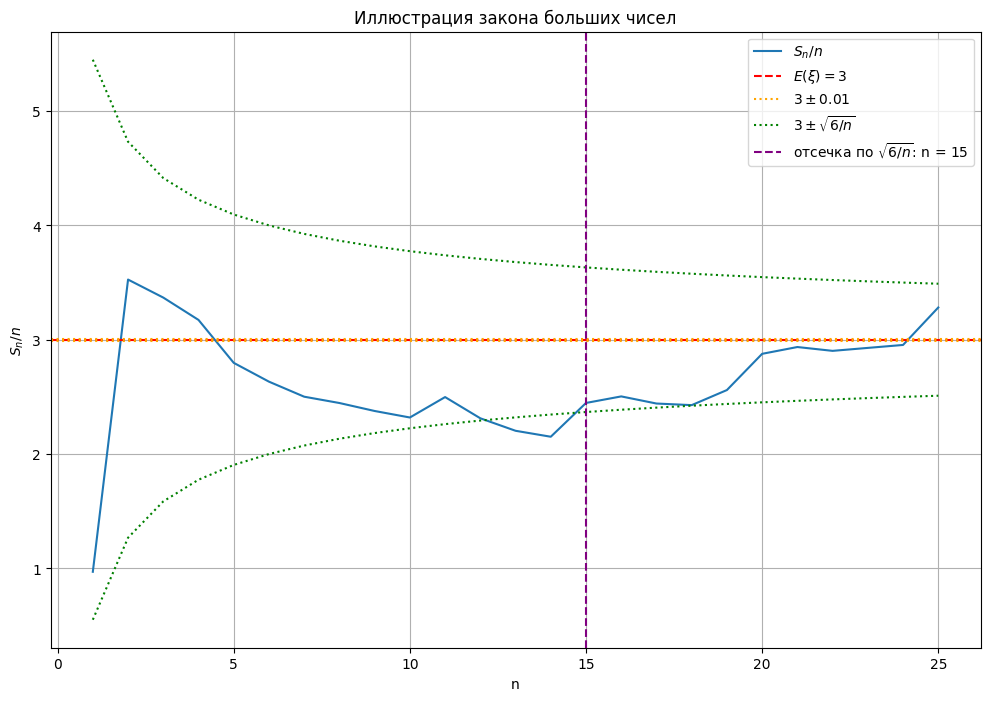

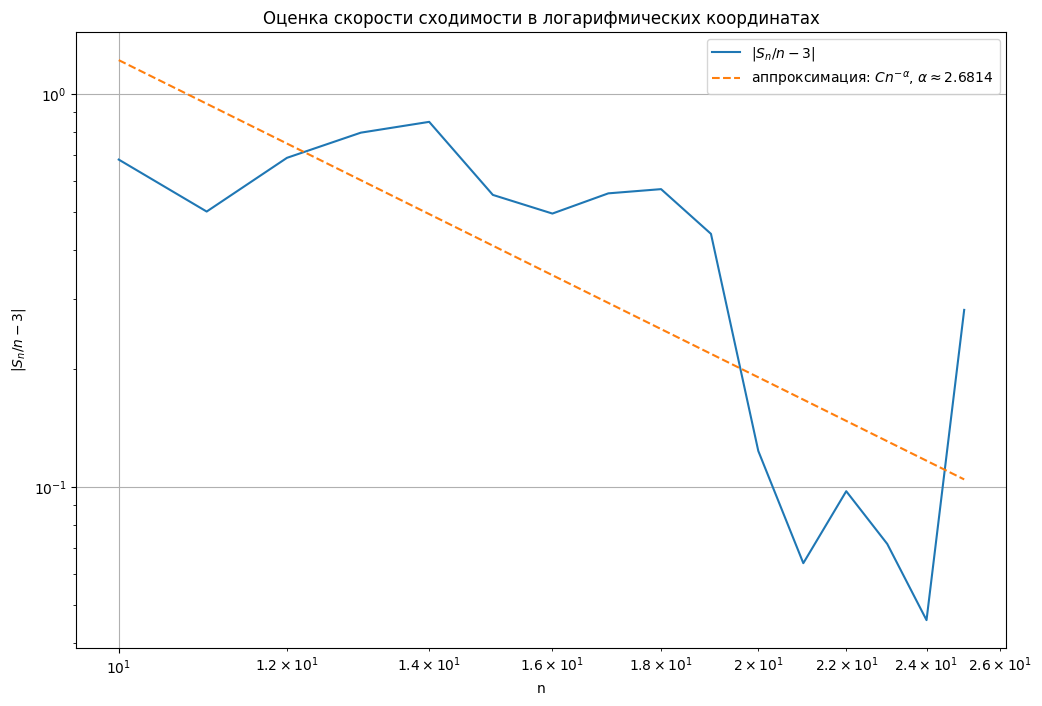

Оценка alpha = 2.681404
Оценка C = 585.135477


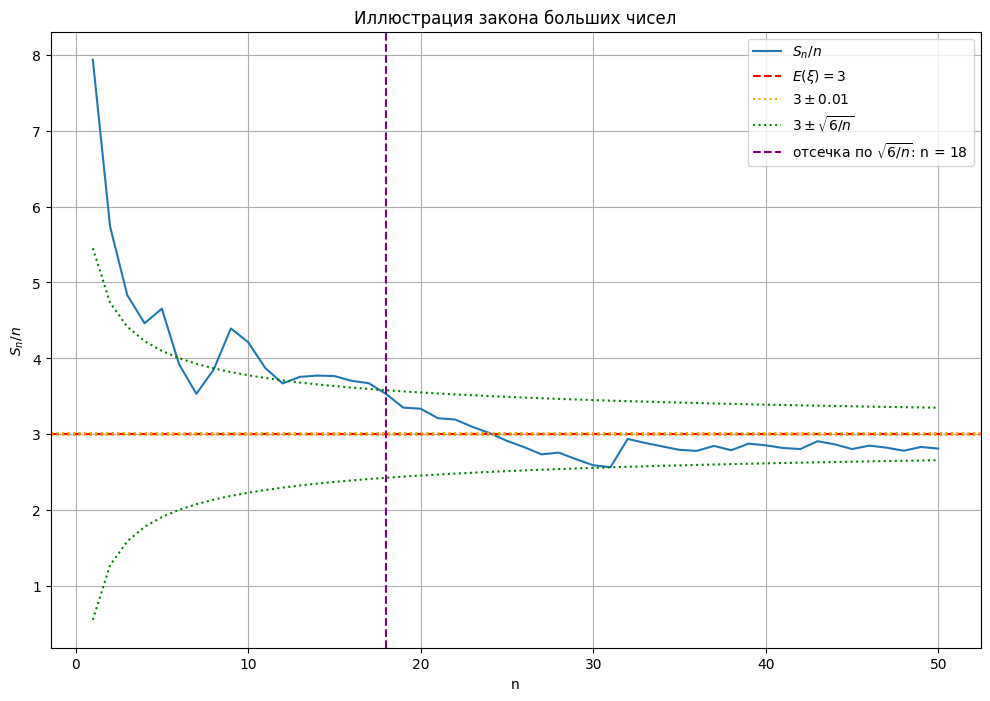

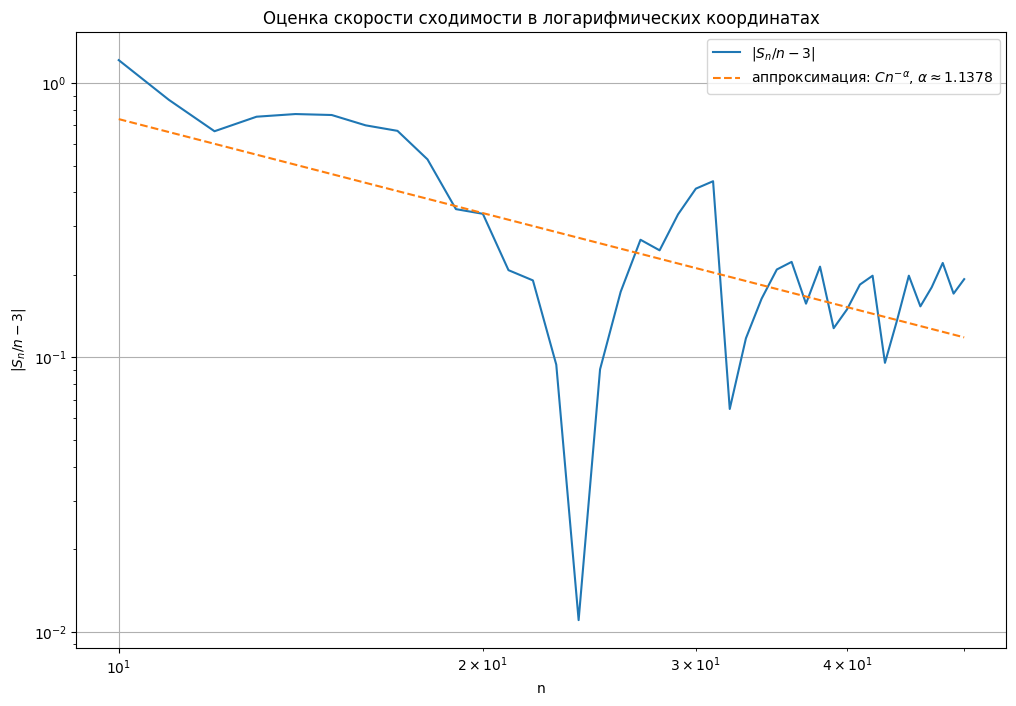

Оценка alpha = 1.137824
Оценка C = 10.142827


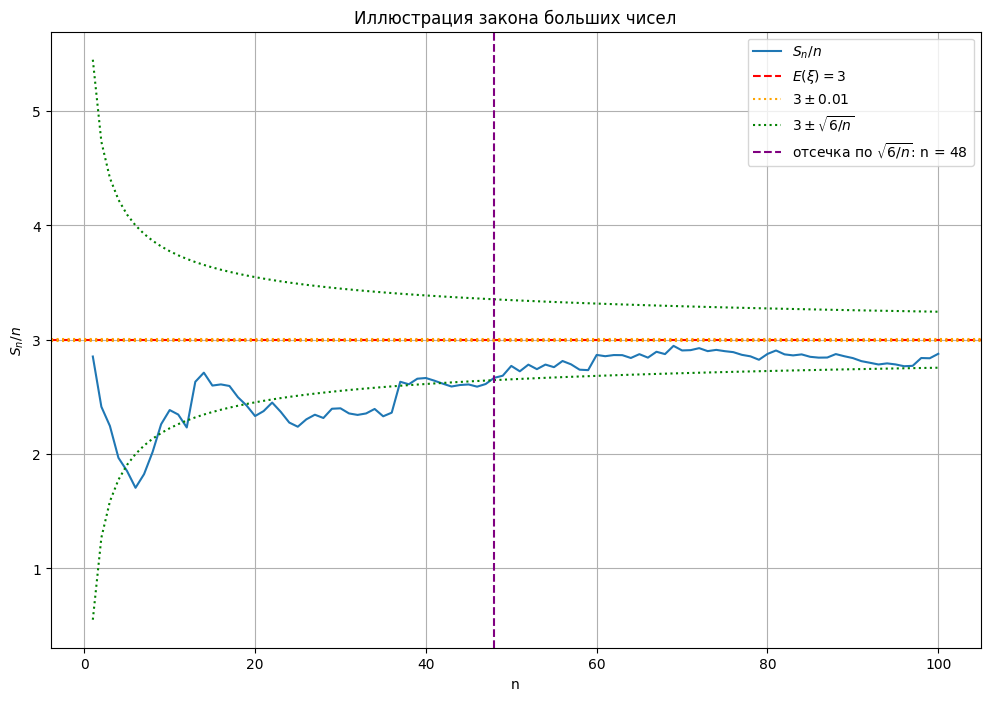

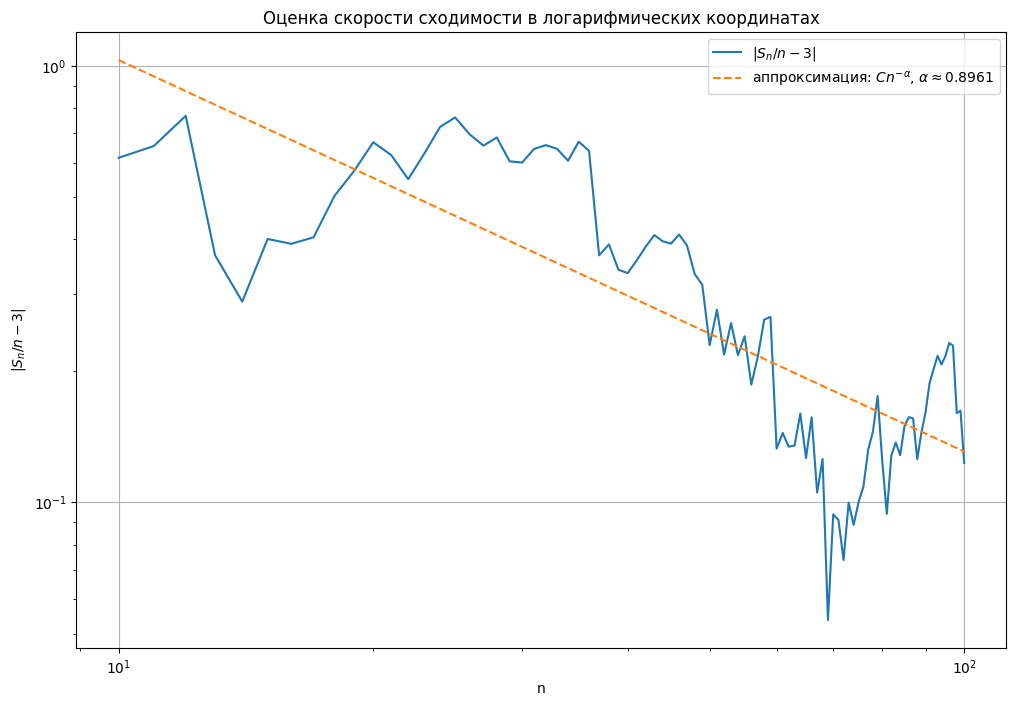

Оценка alpha = 0.896062
Оценка C = 8.104965


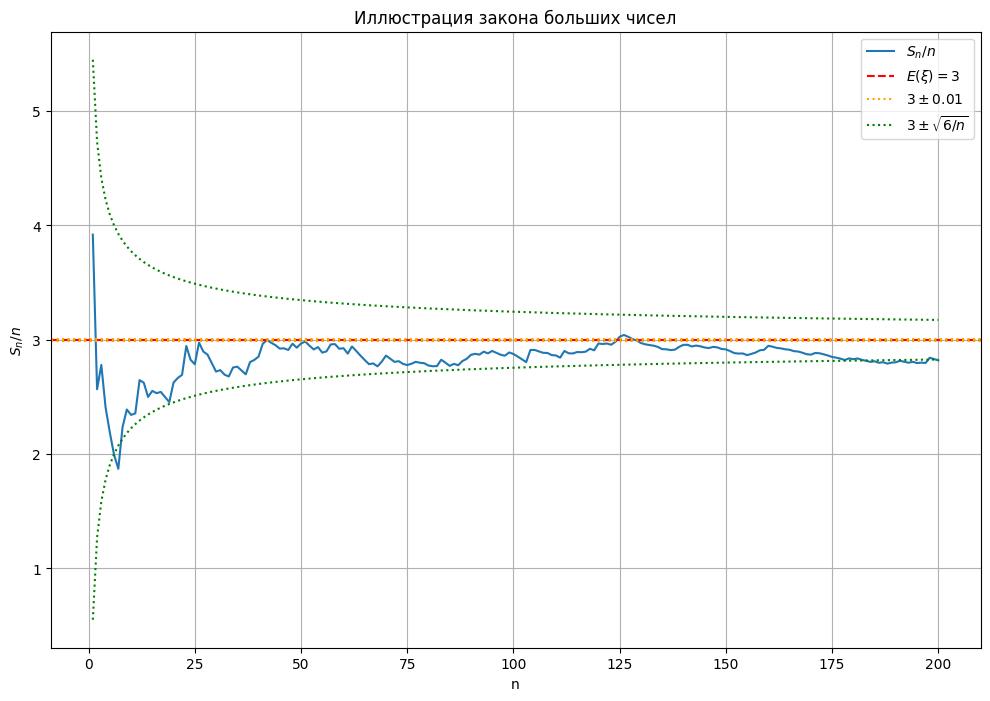

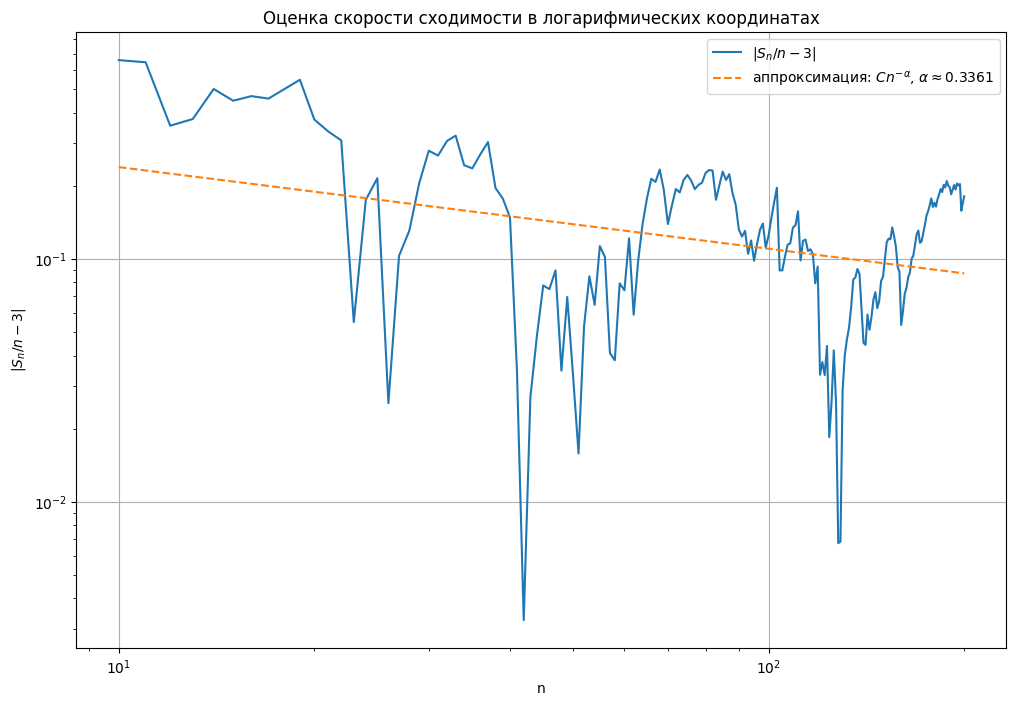

Оценка alpha = 0.336107
Оценка C = 0.517177


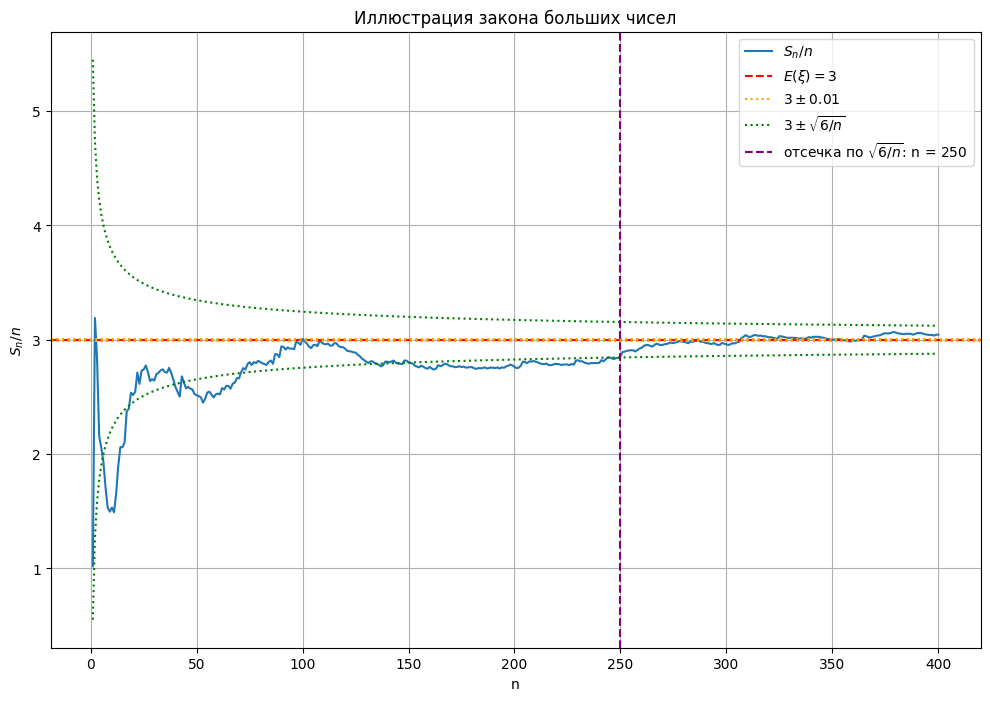

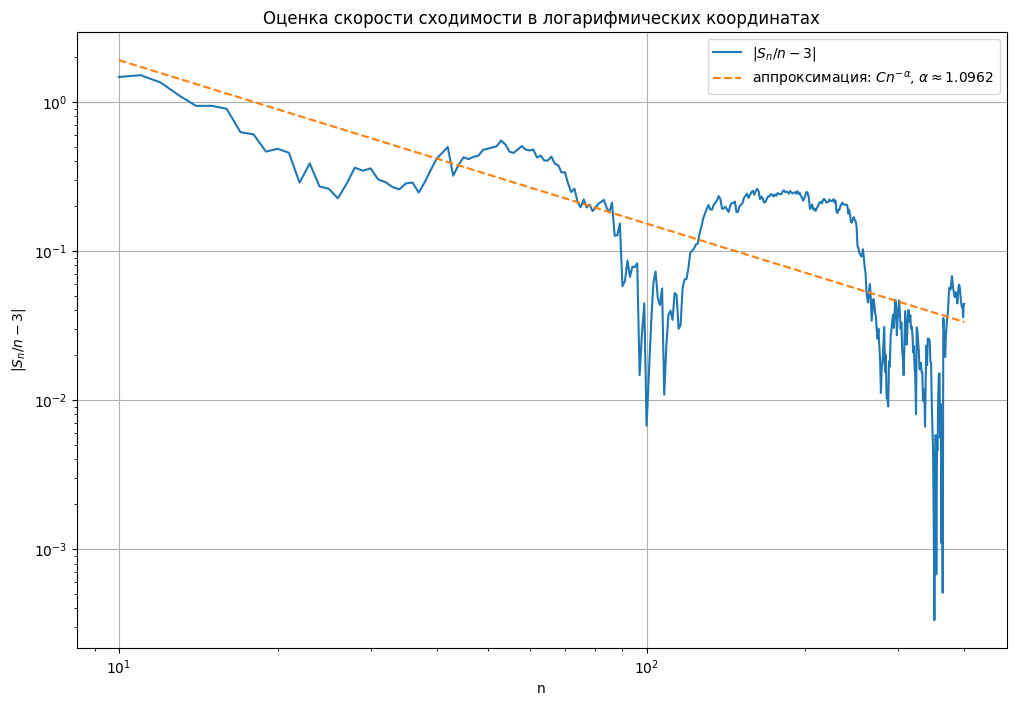

Оценка alpha = 1.096245
Оценка C = 23.762651


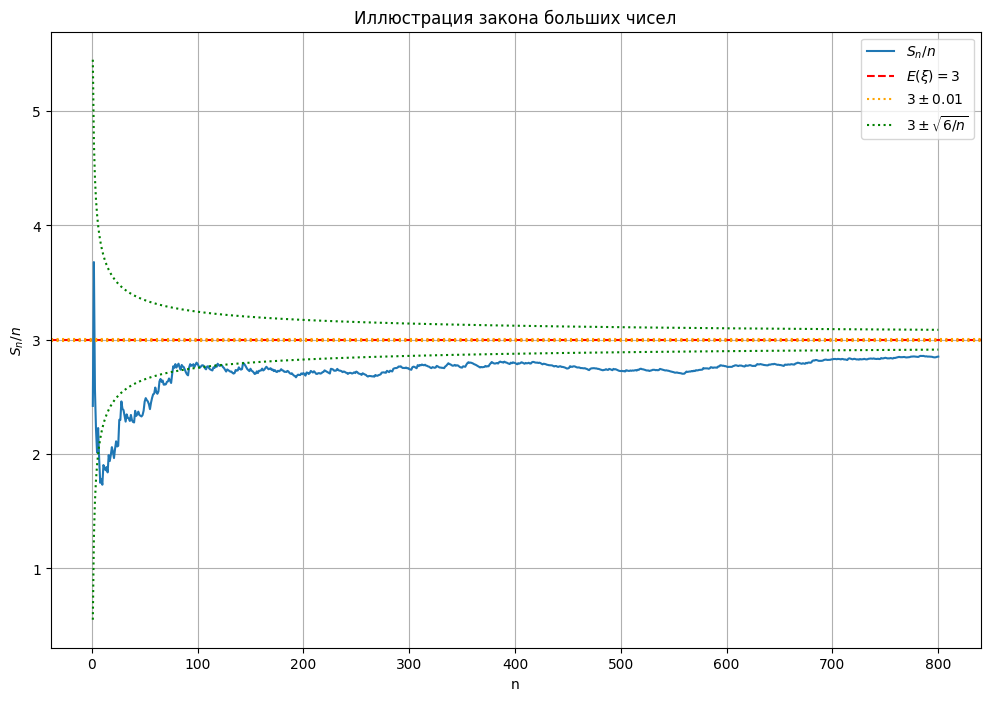

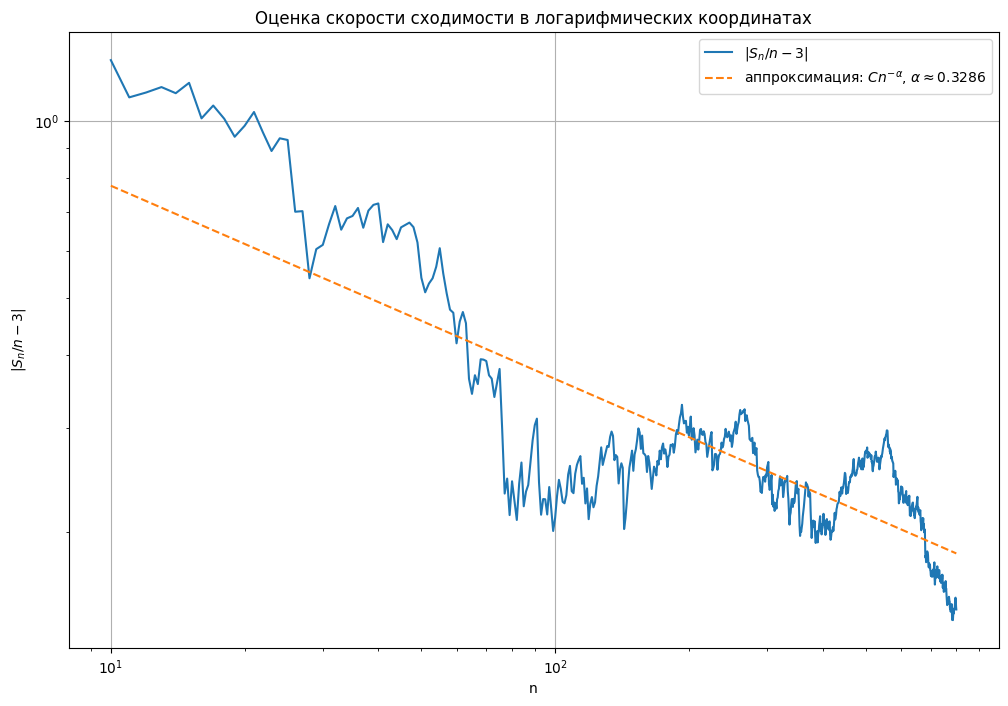

Оценка alpha = 0.328641
Оценка C = 1.652952


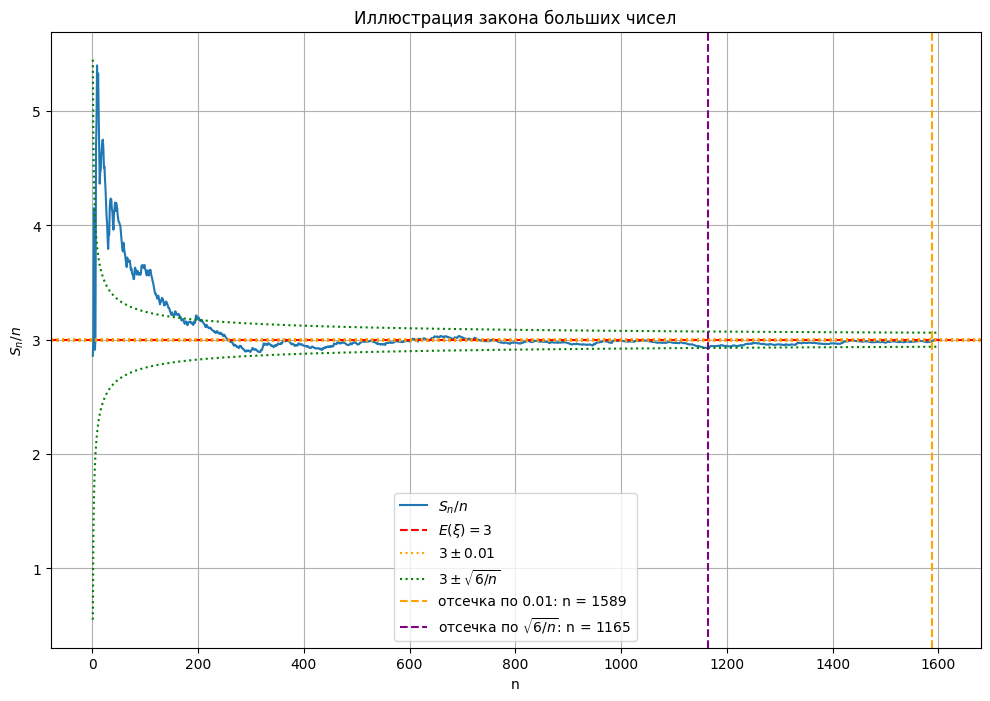

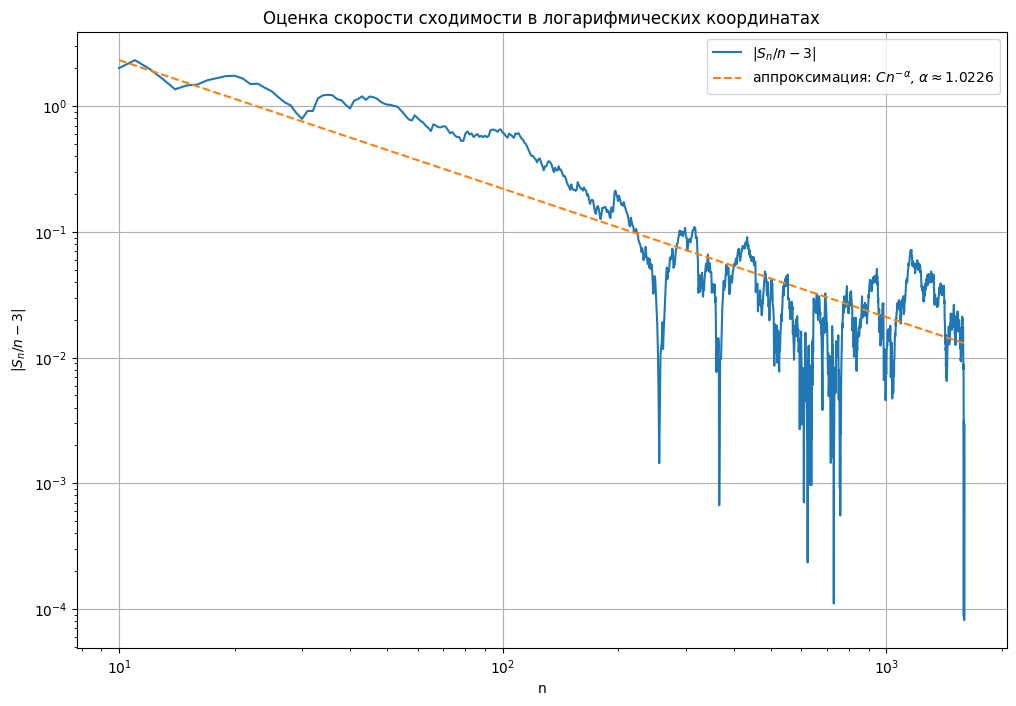

Оценка alpha = 1.022630
Оценка C = 24.562326


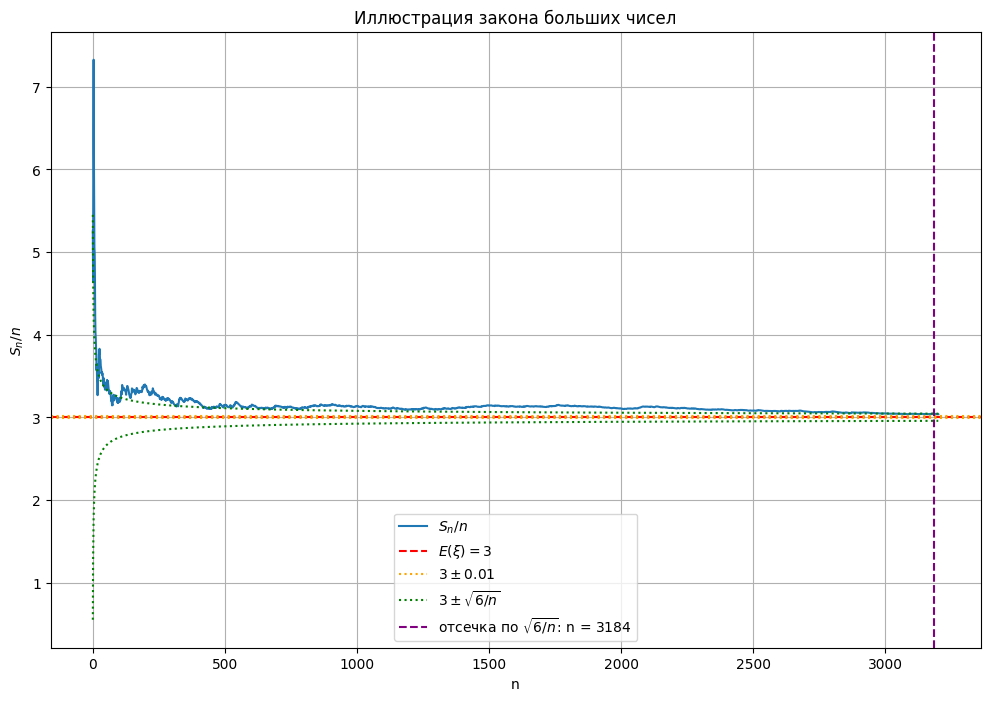

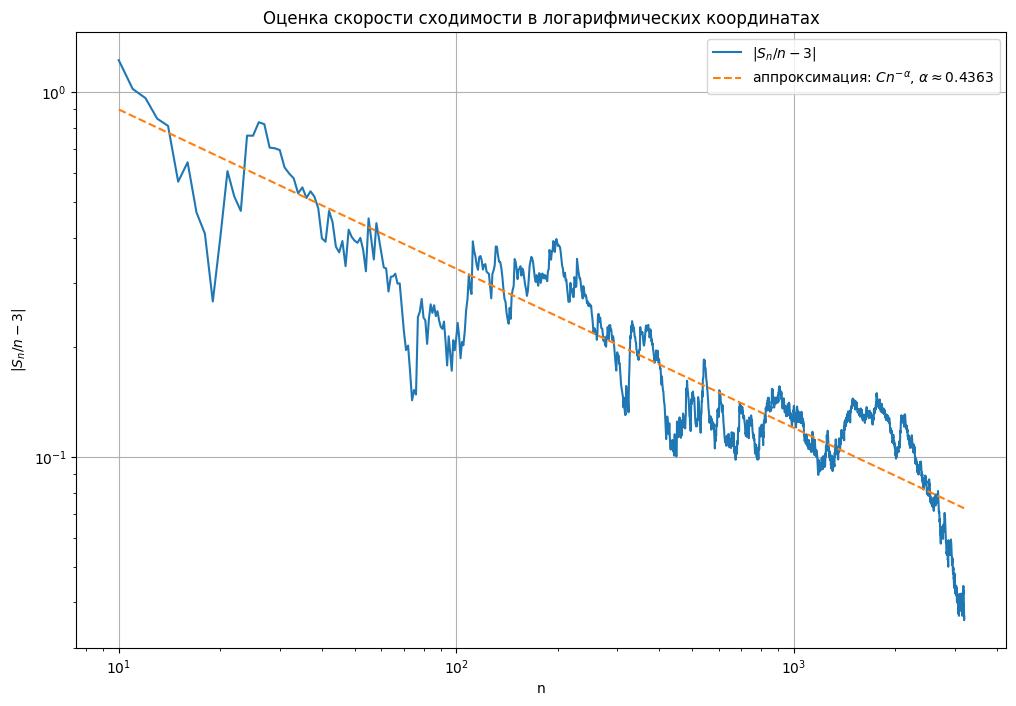

Оценка alpha = 0.436307
Оценка C = 2.452683


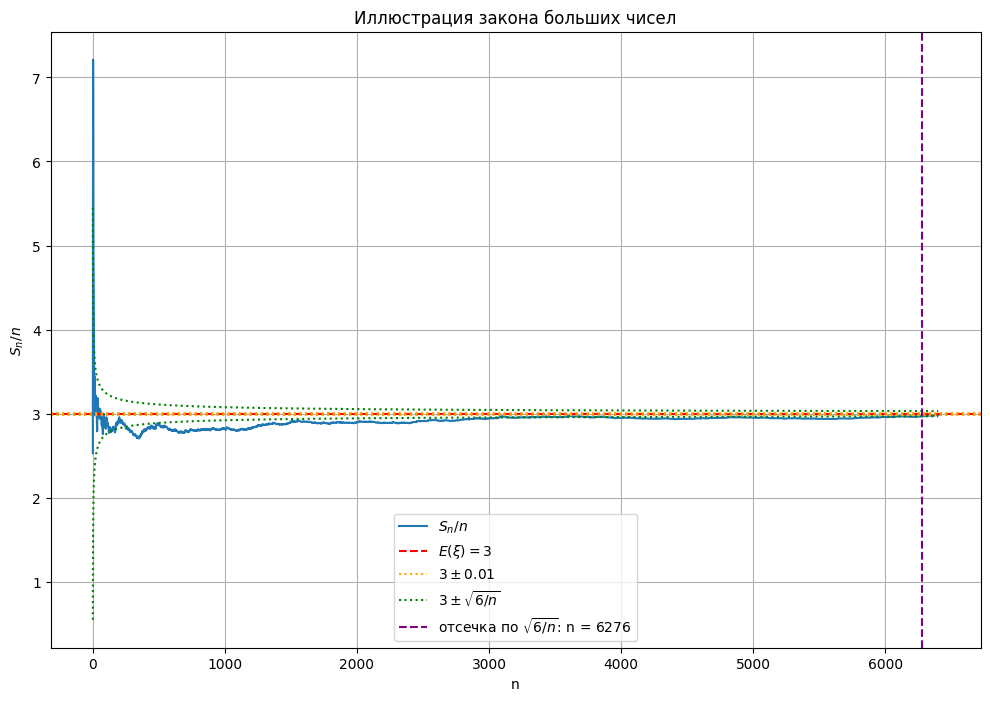

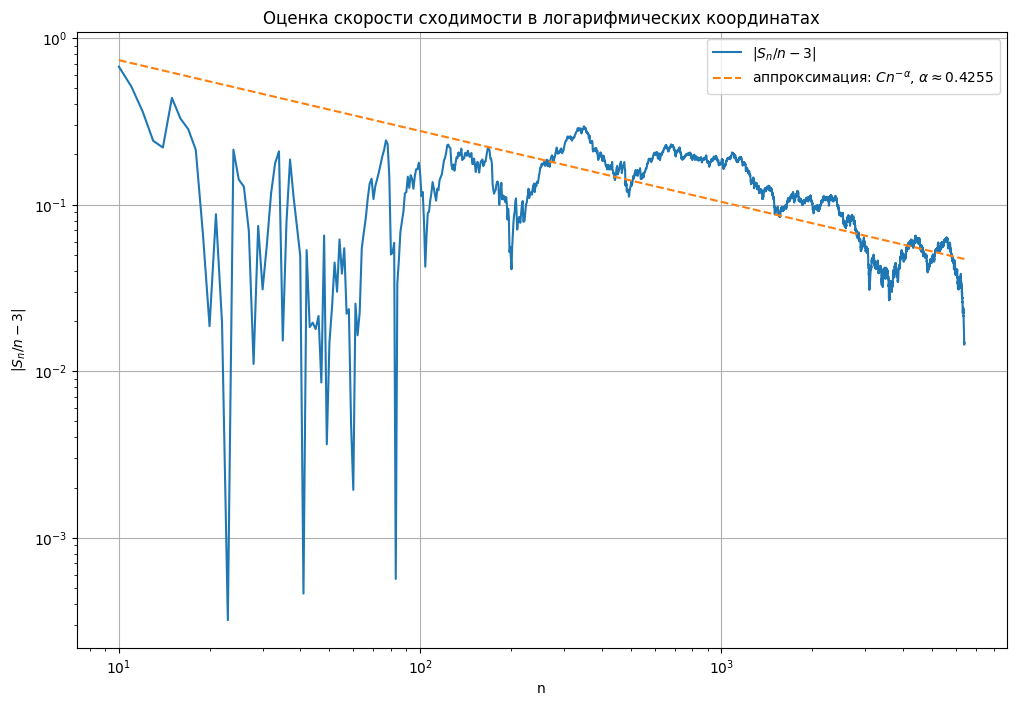

Оценка alpha = 0.425547
Оценка C = 1.964621


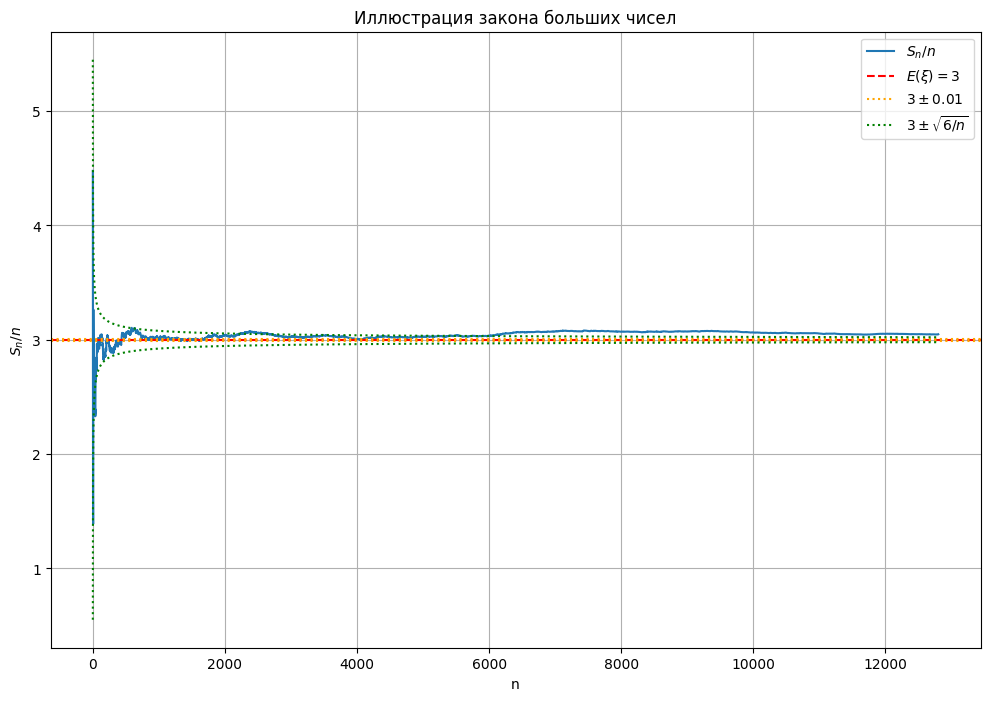

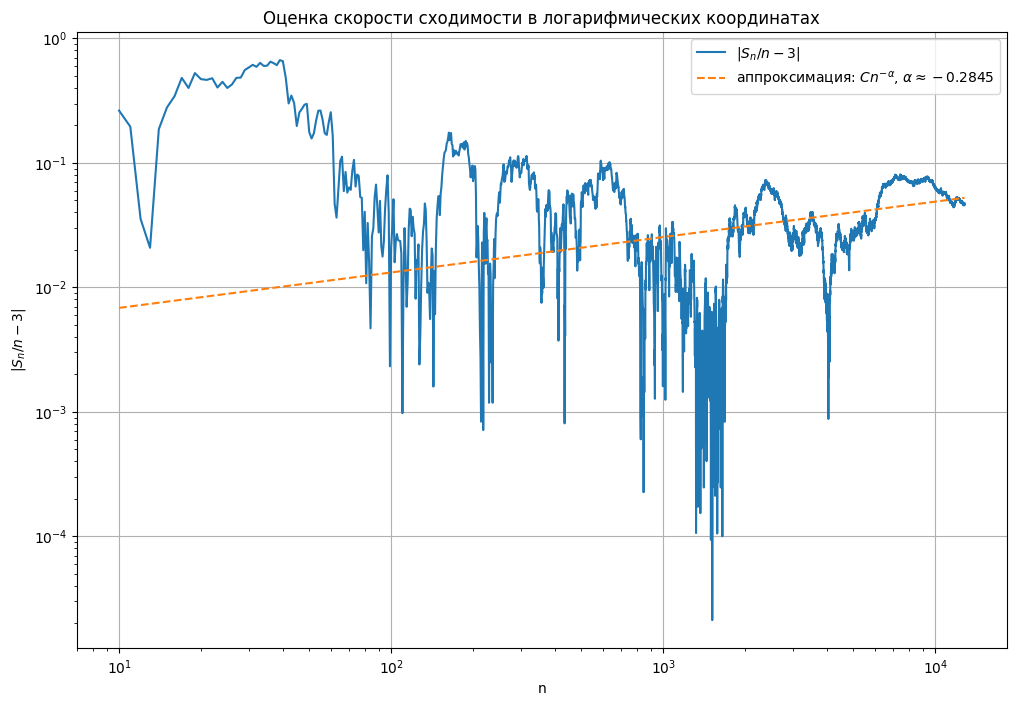

Оценка alpha = -0.284523
Оценка C = 0.003555


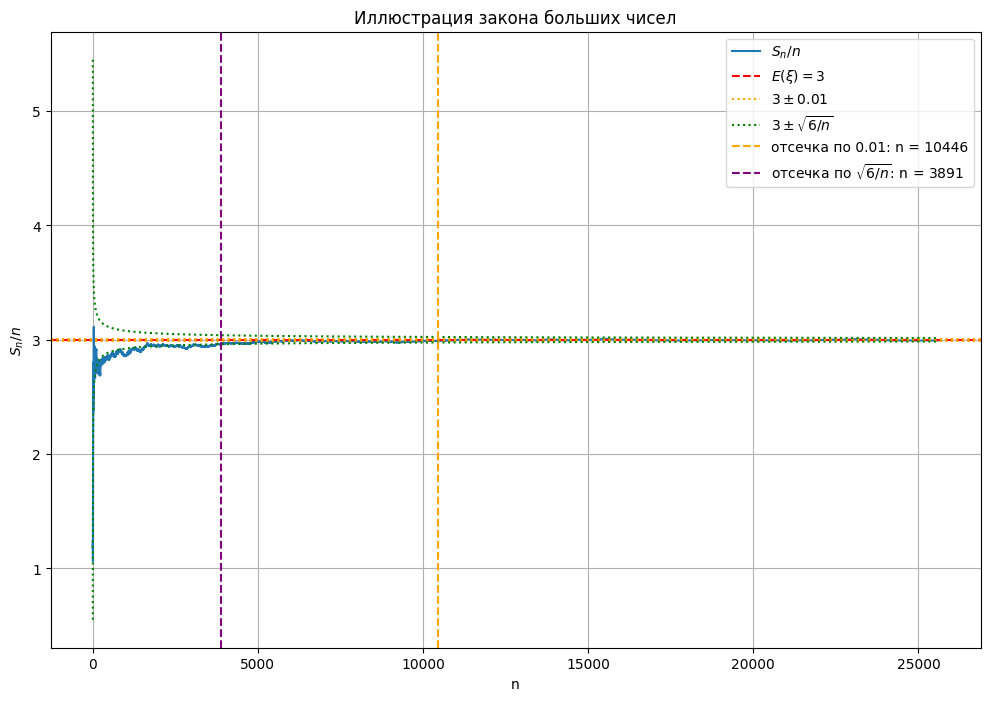

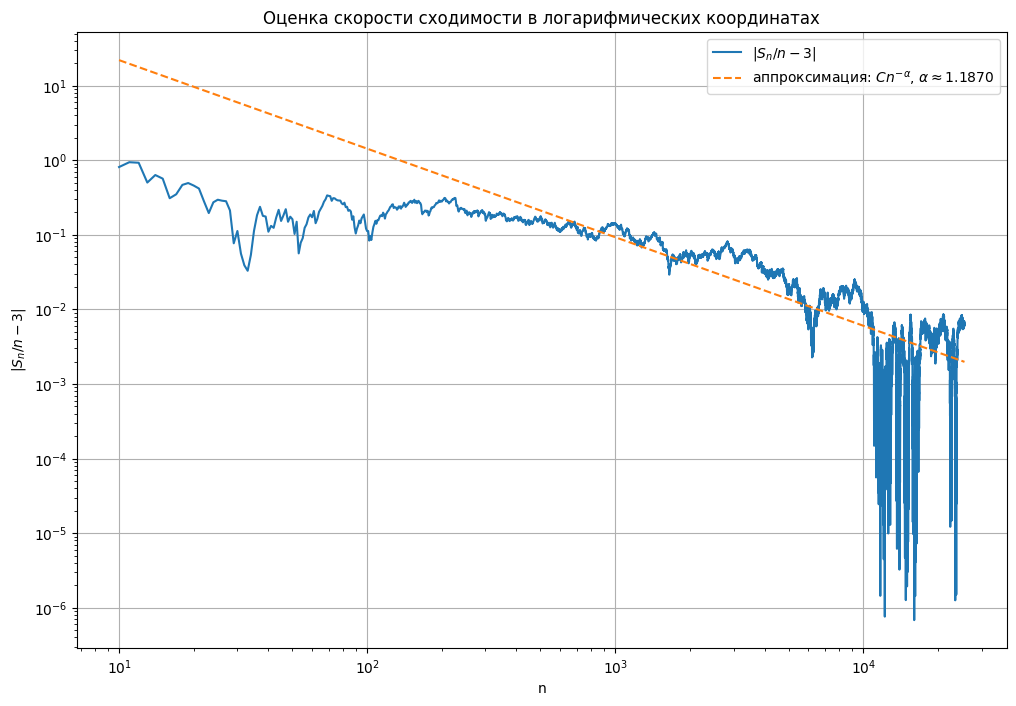

Оценка alpha = 1.187037
Оценка C = 338.307932


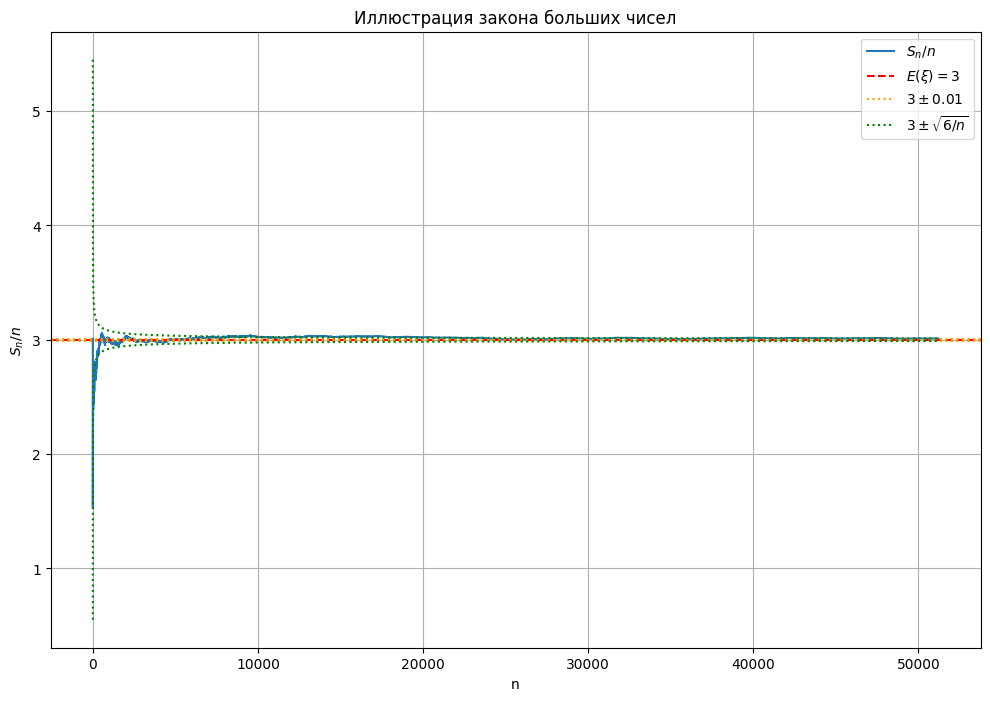

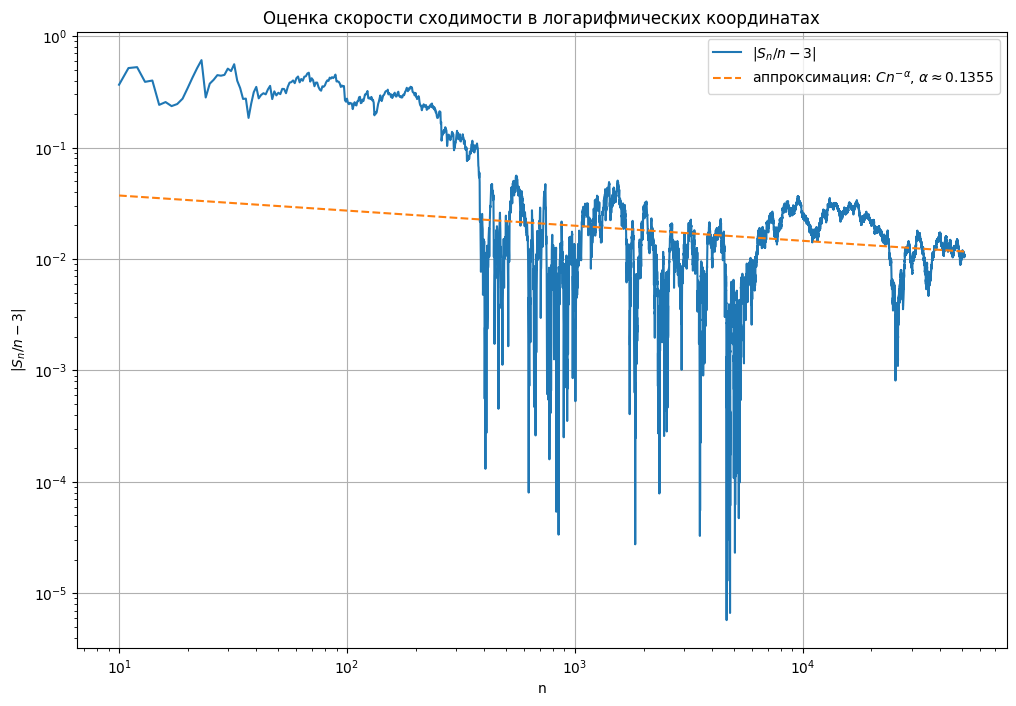

Оценка alpha = 0.135505
Оценка C = 0.050757


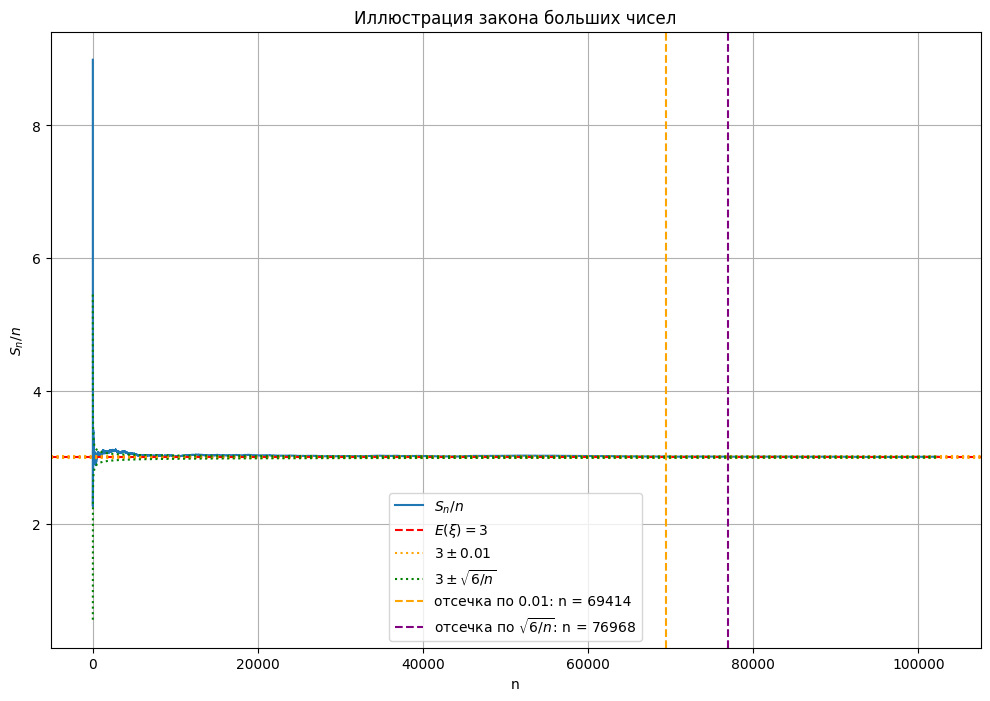

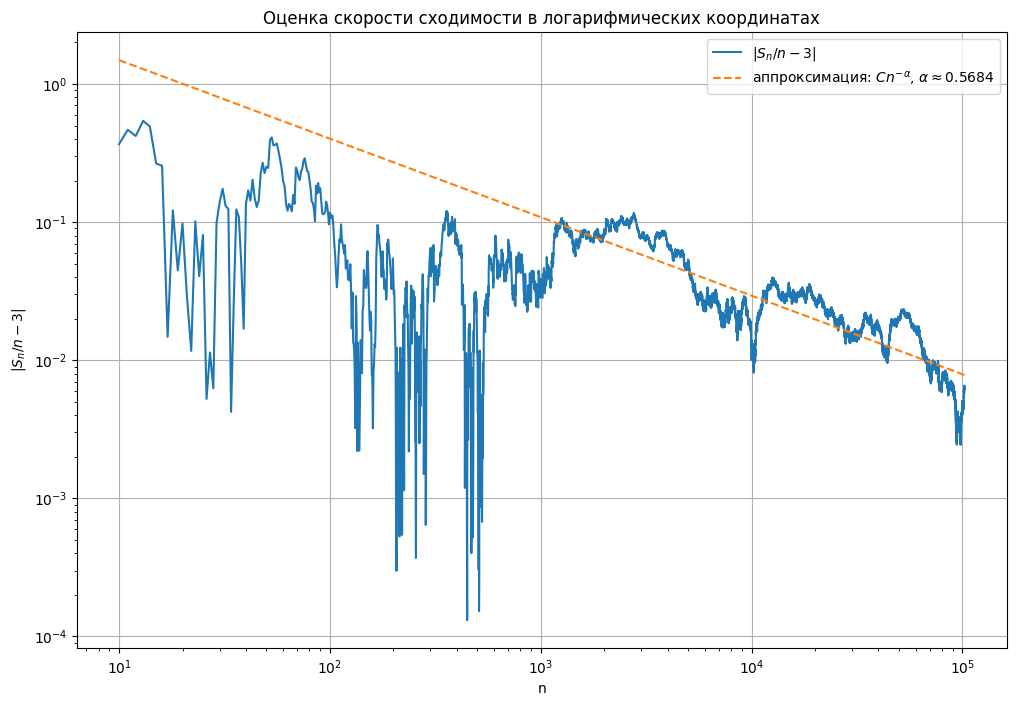

Оценка alpha = 0.568396
Оценка C = 5.510650


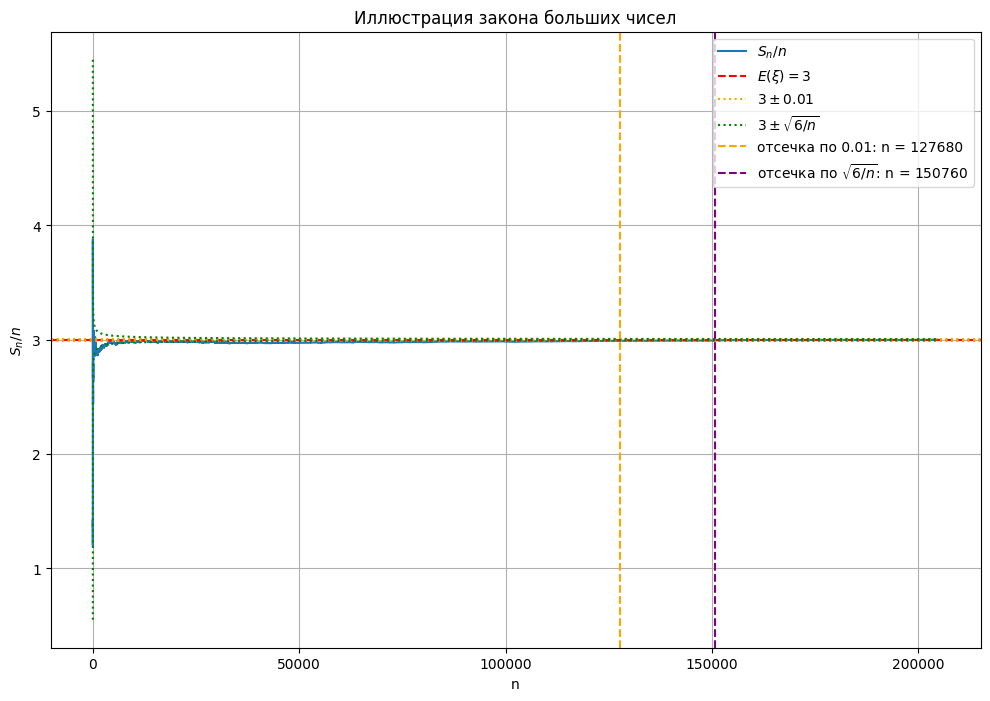

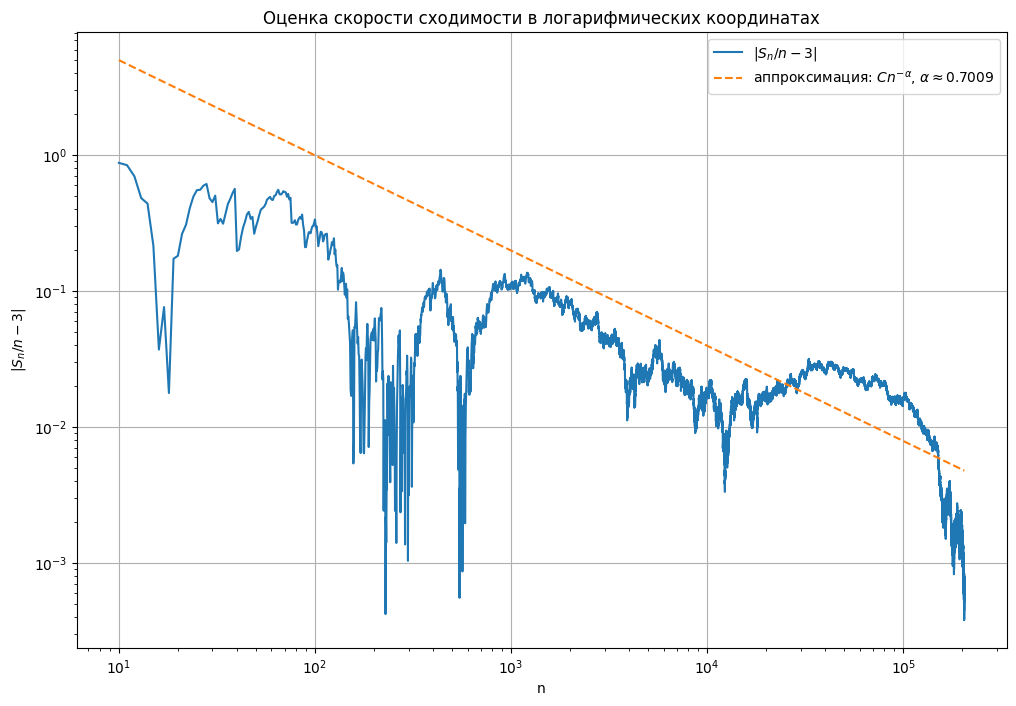

Оценка alpha = 0.700900
Оценка C = 25.187626


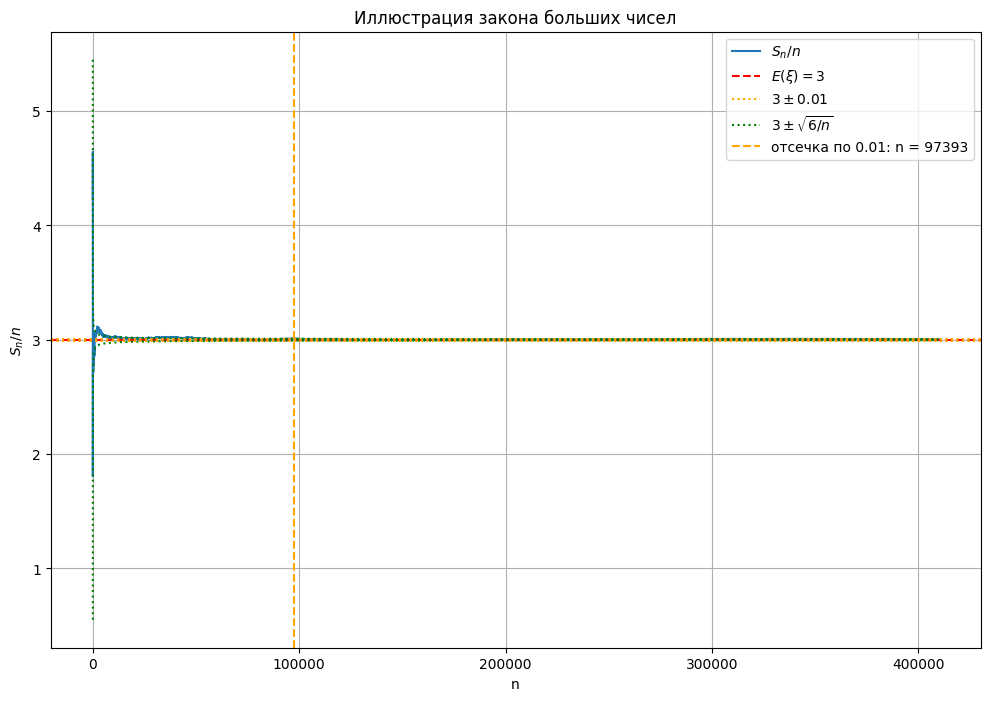

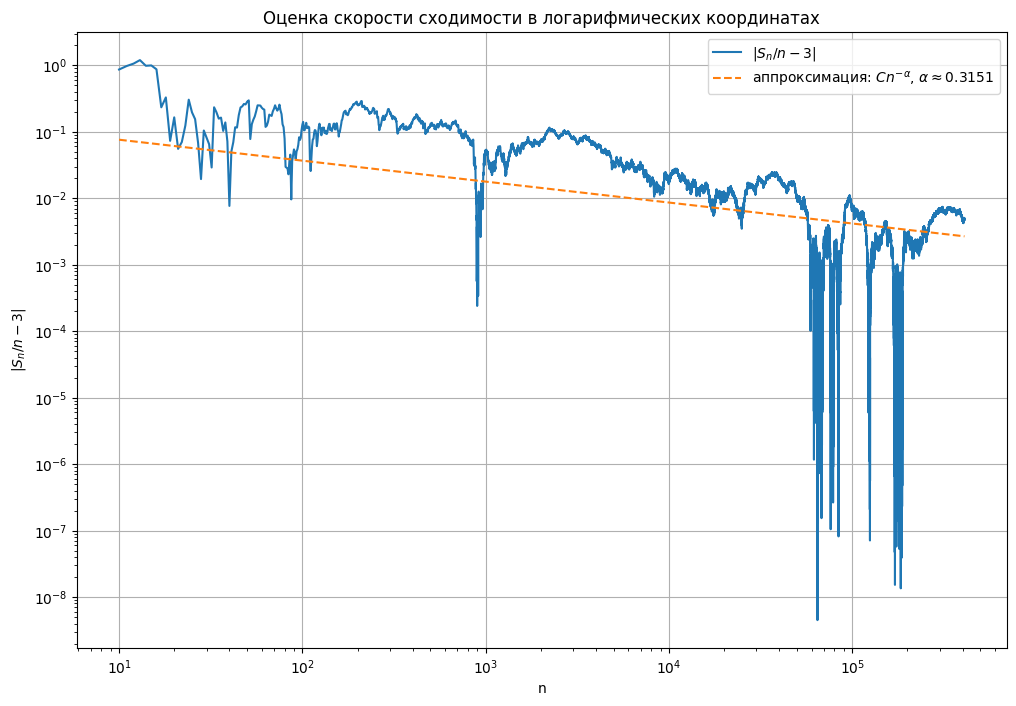

Оценка alpha = 0.315134
Оценка C = 0.156826


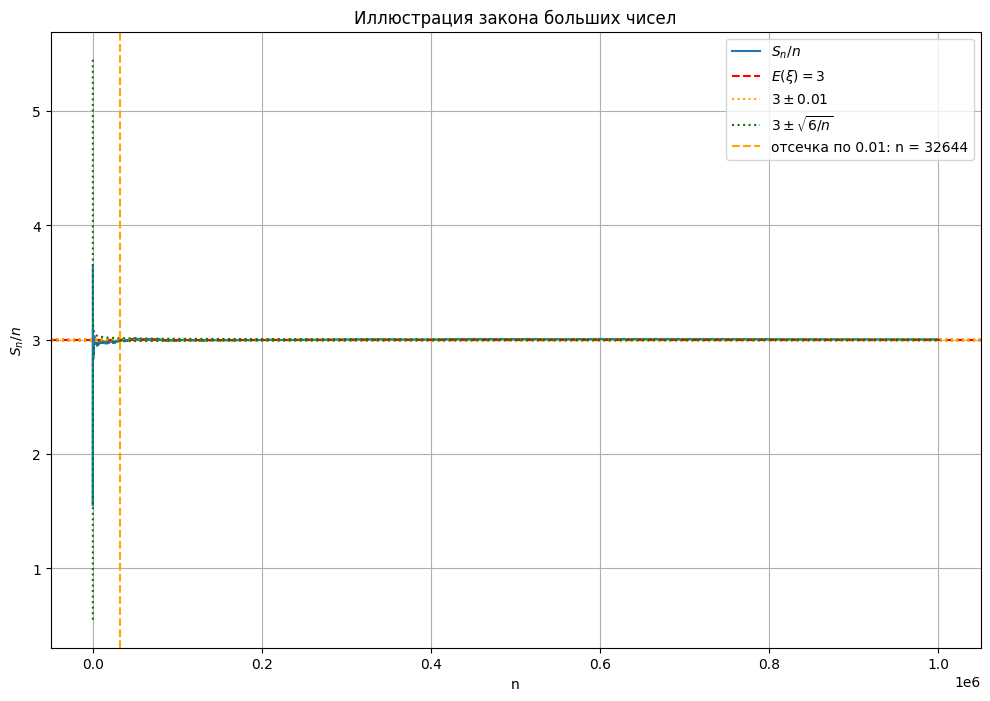

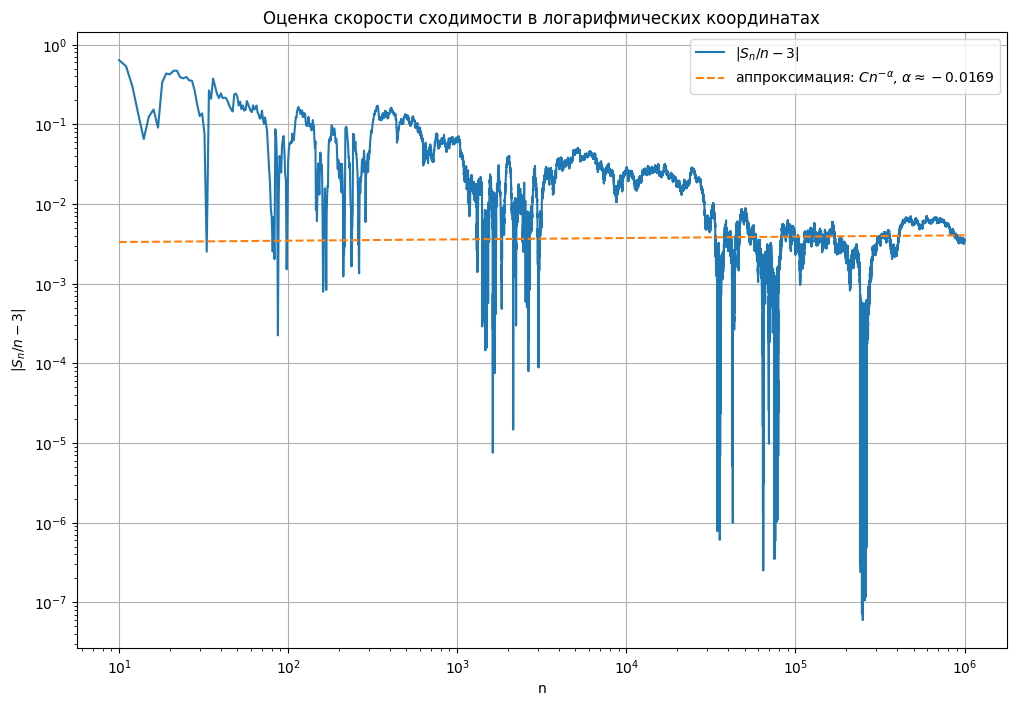

Оценка alpha = -0.016926
Оценка C = 0.003196


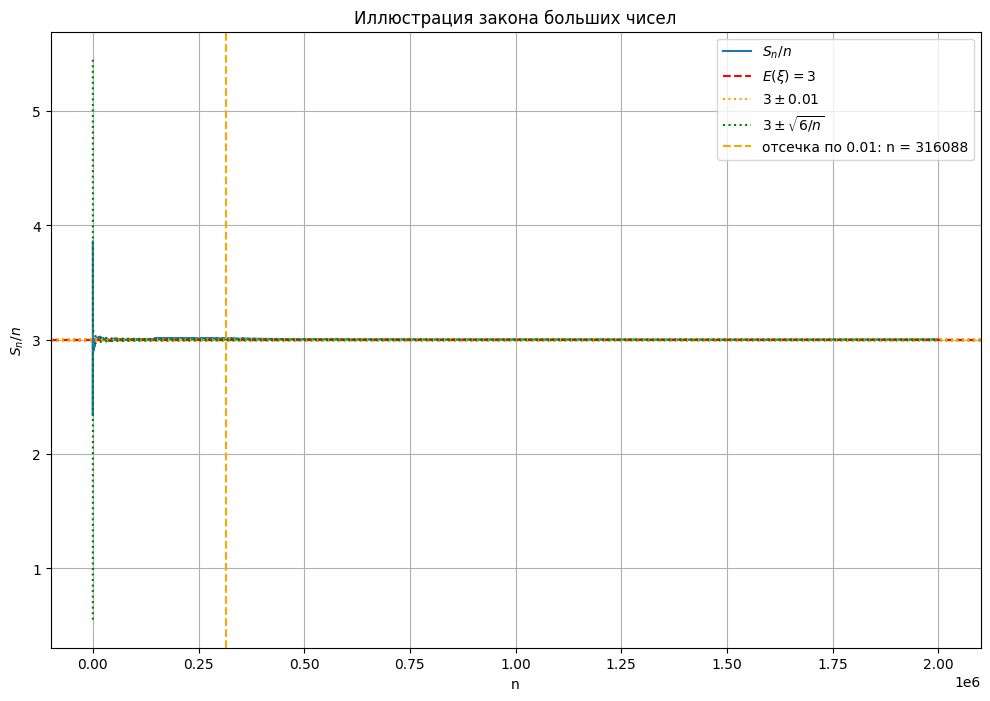

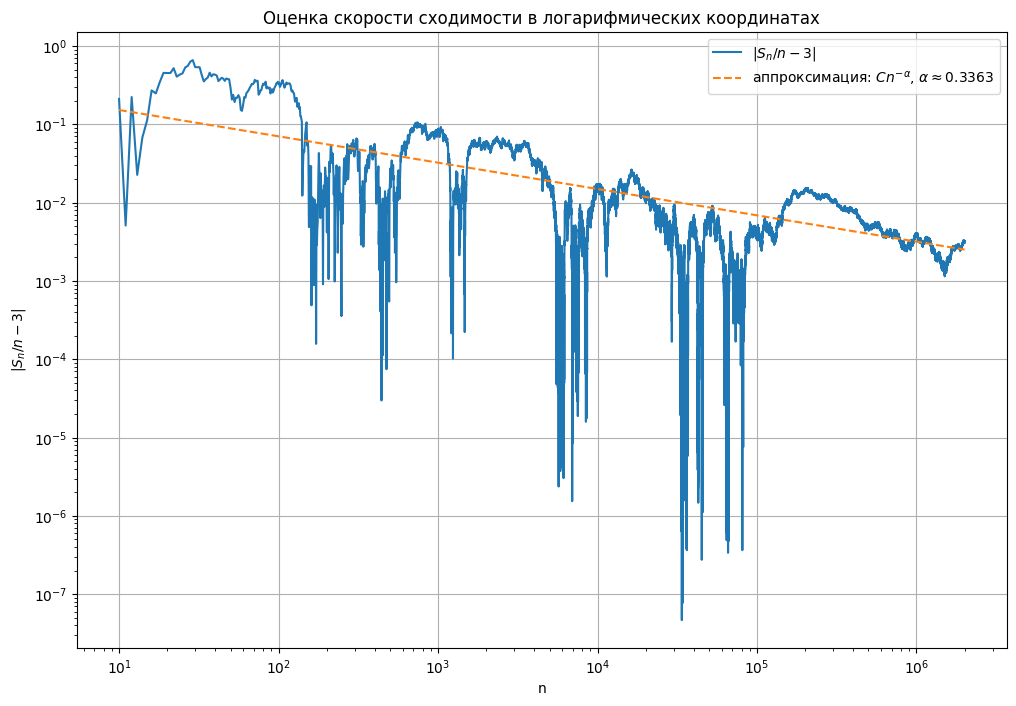

Оценка alpha = 0.336281
Оценка C = 0.331044


c:\Users\Cyber Kanojo\Desktop\programming\Mathematical_statistics\Mathematical_statistics\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


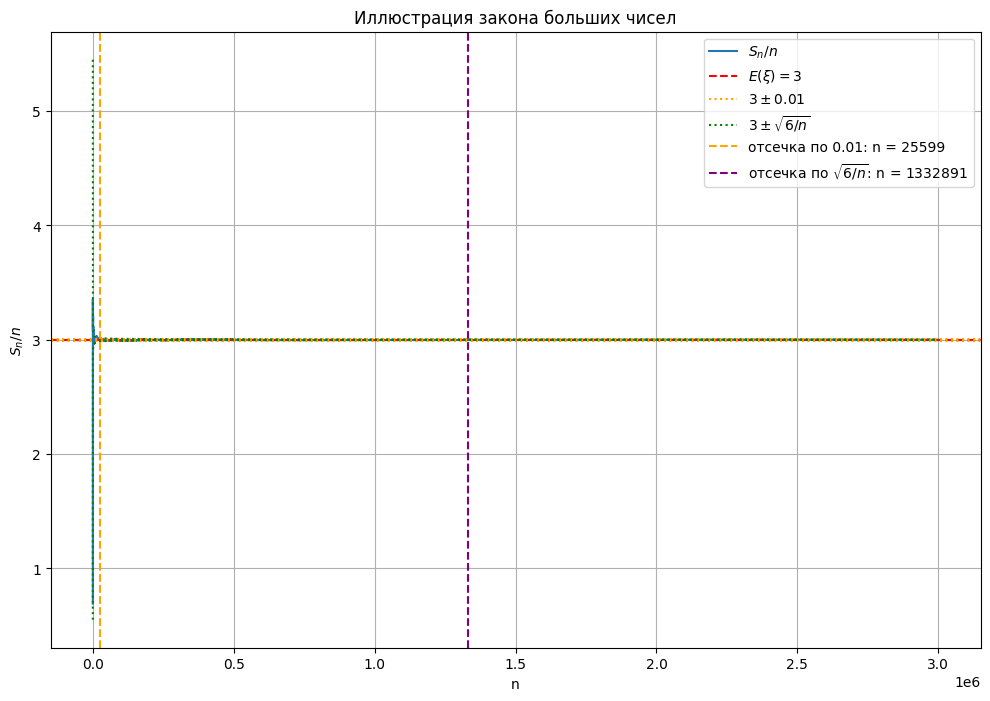

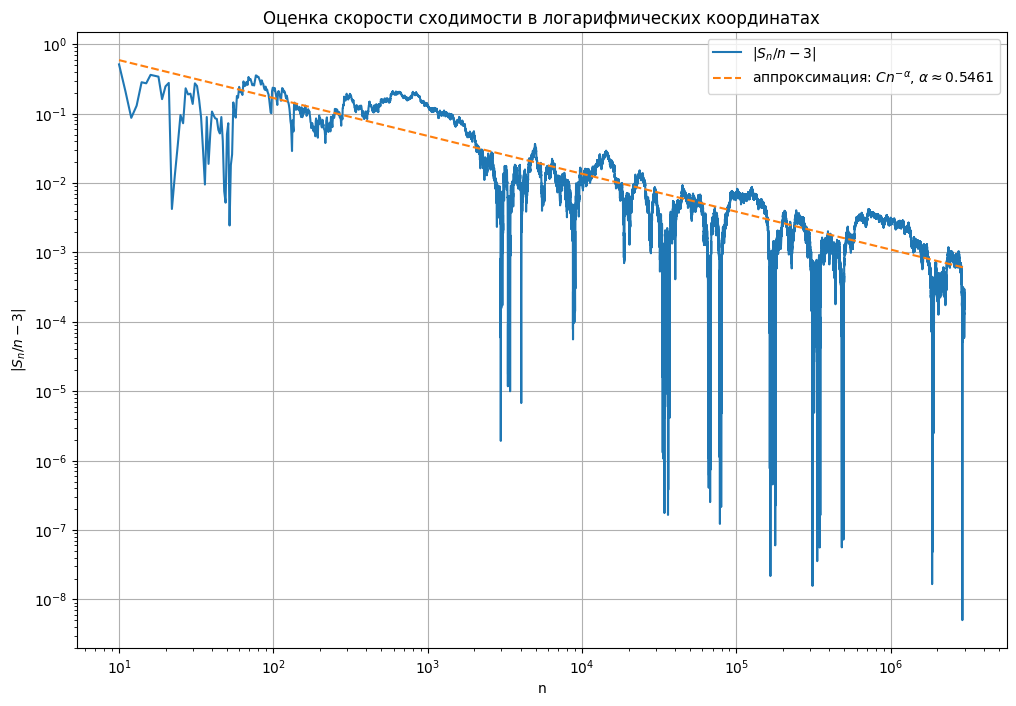

Оценка alpha = 0.546072
Оценка C = 2.075157


In [9]:
counter = 25
while (counter < 500_000):
    sample_mean = sample(N=counter)
    illustration(sample_mean)
    plot_estimate_rate(sample_mean)
    counter *= 2

sample_mean = sample(N=1_000_000)
illustration(sample_mean)
plot_estimate_rate(sample_mean)

sample_mean = sample(N=2_000_000)
illustration(sample_mean)
plot_estimate_rate(sample_mean)

sample_mean = sample(N=3_000_000)
illustration(sample_mean)
plot_estimate_rate(sample_mean)